# EDA IDMT-STM-Guitar

L'exécution de ce notebook a pour prérequis :
- Le téléchargement du dataset `IDMT-SMT-Guitar`,
- le démarrage de l'infrastructure docker,
- l'ingestion du dataset `IDMT-SMT-Guitar`.

Pour télécharger le dataset `IDMT-SMT-Guitar`, utilisez la commande :
```bash
uv run ./audio_midi/main.py --download_datasets --no_guitar_set
```

Pour démarrer l'infrastructure docker, utilisez la commande :
```bash
docker-compose up -d
```

Pour lancer la pipeline d'ingestion, utilisez la commande :
```bash
uv run ./audio_midi/main.py --ingest_idmt_smt_guitar
```

## Imports

In [1]:
import sys
from pathlib import Path

AUDIO_MIDI_DIRECTORY = Path.cwd().parent
sys.path.append(AUDIO_MIDI_DIRECTORY.as_posix())

In [2]:
# Chemins
OUTPUT_DIRECTORY = AUDIO_MIDI_DIRECTORY / "output"
EDA_IDM_SMT_GUITAR_DIRECTORY = OUTPUT_DIRECTORY / "eda_idmt_smt_guitar"
FIGURES_DIRECTORY = EDA_IDM_SMT_GUITAR_DIRECTORY / "figures"
LATEX_DIRECTORY = EDA_IDM_SMT_GUITAR_DIRECTORY / "latex"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
EDA_IDM_SMT_GUITAR_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LATEX_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports EDA
from typing import Callable
import warnings
import pandas as pd
import numpy as np
from scipy import stats
import pretty_midi
import librosa

warnings.filterwarnings("ignore")

RANDOM_STATE = 73

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports storages
import logging
from src.storages import PostgresStorage
from src.storages import MongoStorage
from src.storages import MinIOStorage

from settings import MINIO_SETTINGS

postgres = PostgresStorage(logger=logging.getLogger())
mongo = MongoStorage(logger=logging.getLogger())
minio = MinIOStorage(logger=logging.getLogger())

## Sous Dataset 2

### Métadonnées (PostgreSQL)

In [ ]:
df_metadata = pd.DataFrame(
    postgres.select_all_idmt_smt_guitar_metadata(dataset_number=2)
)
df_metadata = df_metadata.drop(columns=["id_recording", "dataset_name"])
df_metadata["recording_date"] = pd.to_datetime(df_metadata["recording_date"])
df_metadata["pick_up_setting"] = df_metadata["pick_up_setting"].map({"unknown": None})
df_metadata["instrument_body_material"] = df_metadata["instrument_body_material"].map(
    {"unknown": None}
)

df_metadata.head()

,title,instrument,instrument_model,pick_up_setting,instrument_tuning,audio_effects,recording_date,recording_artist,instrument_body_material,instrument_string_material,composer,recording_source
0,AR_A_muted5,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
1,AR_B_fret_0-20,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
2,AR_B_muted5,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
3,AR_DN_III_VIII_XIV,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
4,AR_D_fret_0-20,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None


In [16]:
df_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype        
---  ------                      --------------  -----        
 0   title                       261 non-null    str          
 1   instrument                  261 non-null    str          
 2   instrument_model            261 non-null    str          
 3   pick_up_setting             0 non-null      object       
 4   instrument_tuning           261 non-null    str          
 5   audio_effects               0 non-null      object       
 6   recording_date              261 non-null    datetime64[s]
 7   recording_artist            261 non-null    str          
 8   instrument_body_material    0 non-null      object       
 9   instrument_string_material  261 non-null    str          
 10  composer                    261 non-null    str          
 11  recording_source            0 non-null      object       
dtypes: datetime64[s](1)

Observations :
- Les variables sont toutes catégorielles à l'exeption de `recording_date` qui est de type date.
- Les colonnes `pick_up_setting`, `audio_effects`, `instrument_body_material` et `recording_source` sont nulles.

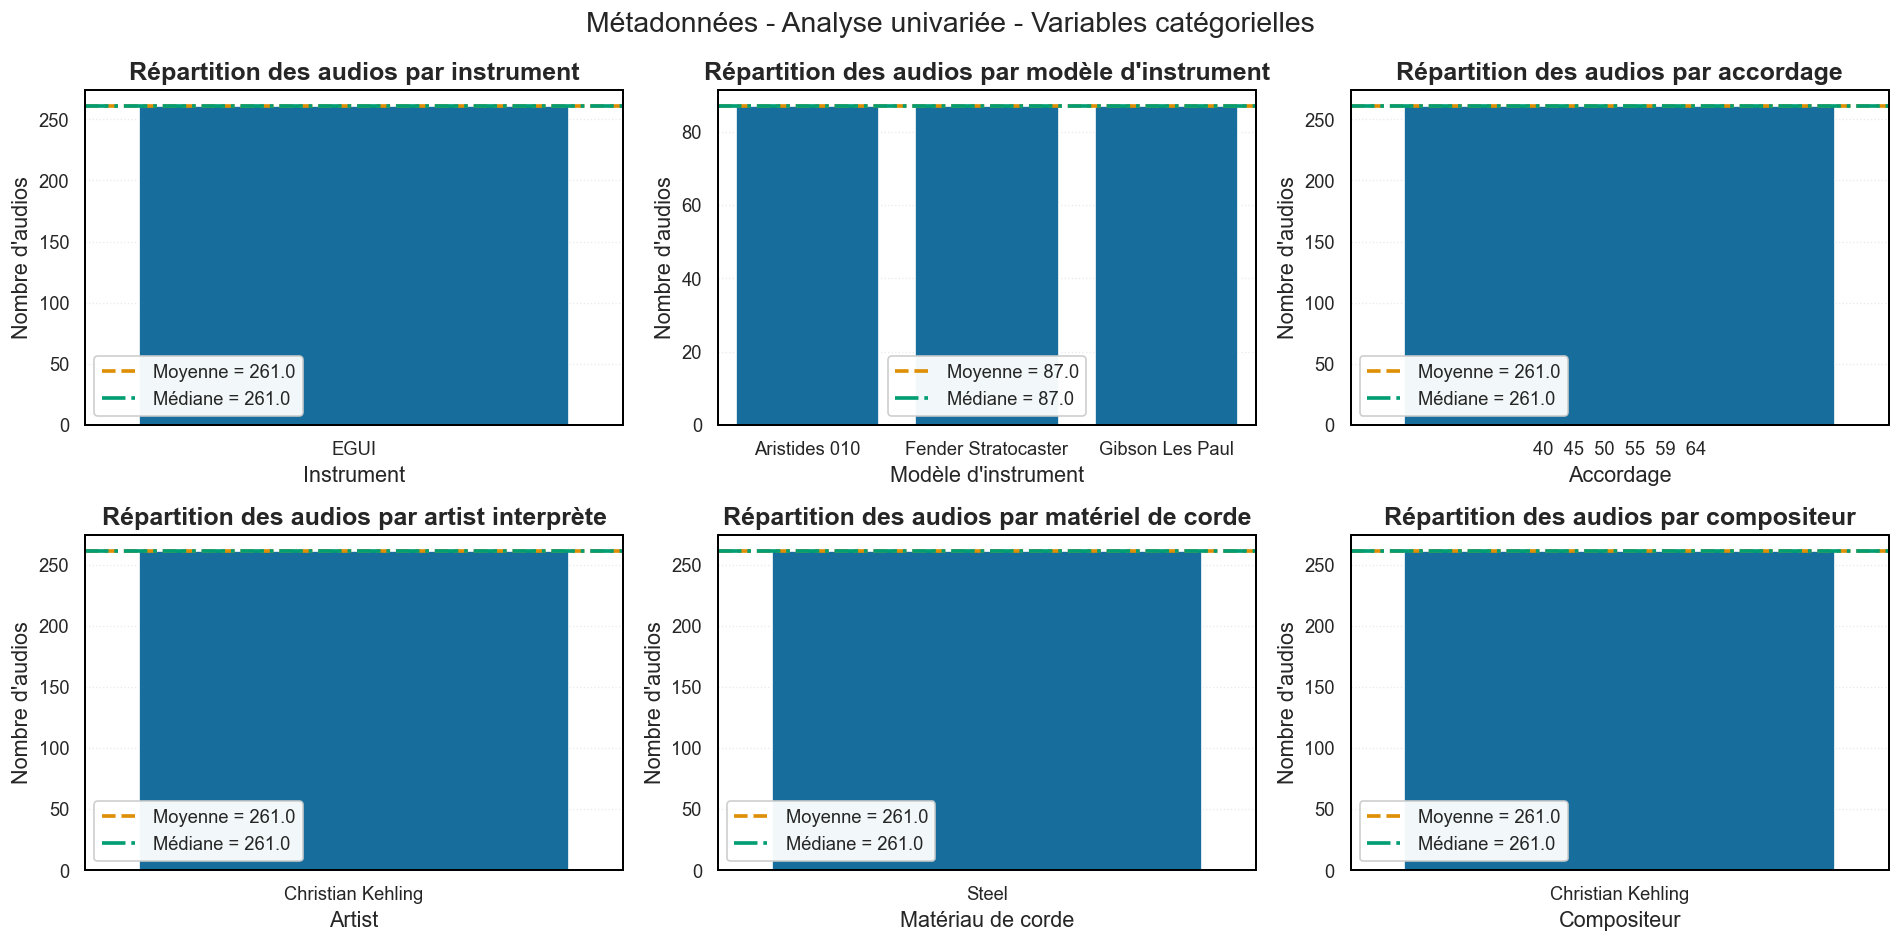

In [19]:
def create_barplot(ax, df, column, rotation=0):
    df_grpby = df.groupby(column).agg(size=(column, "size")).reset_index()

    sns.barplot(
        data=df_grpby,
        x=column,
        y="size",
        ax=ax,
    )

    mean_column = df_grpby["size"].mean()
    median_column = df_grpby["size"].median()

    ax.axhline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axhline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


fig, axes = plt.subplots(2, 3, figsize=(16, 8))

fig.suptitle("Métadonnées - Analyse univariée - Variables catégorielles", fontsize=17)

# ===
# Répartition des audios par instrument
# ===
ax1 = axes[0, 0]
create_barplot(ax=ax1, df=df_metadata, column="instrument")
ax1.set_title("Répartition des audios par instrument")
ax1.set_xlabel("Instrument")
ax1.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par instrument_model
# ===
ax2 = axes[0, 1]
create_barplot(ax=ax2, df=df_metadata, column="instrument_model", rotation=0)
ax2.set_title("Répartition des audios par modèle d'instrument")
ax2.set_xlabel("Modèle d'instrument")
ax2.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par instrument_tuning
# ===
ax3 = axes[0, 2]
create_barplot(ax=ax3, df=df_metadata, column="instrument_tuning")
ax3.set_title("Répartition des audios par accordage")
ax3.set_xlabel("Accordage")
ax3.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par recording_artist
# ===
ax4 = axes[1, 0]
create_barplot(ax=ax4, df=df_metadata, column="recording_artist")
ax4.set_title("Répartition des audios par artist interprète")
ax4.set_xlabel("Artist")
ax4.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par instrument_string_material
# ===
ax5 = axes[1, 1]
create_barplot(ax=ax5, df=df_metadata, column="instrument_string_material")
ax5.set_title("Répartition des audios par matériel de corde")
ax5.set_xlabel("Matériau de corde")
ax5.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par composer
# ===
ax6 = axes[1, 2]
create_barplot(ax=ax6, df=df_metadata, column="composer")
ax6.set_title("Répartition des audios par compositeur")
ax6.set_xlabel("Compositeur")
ax6.set_ylabel("Nombre d'audios")

fig.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "metadata_categorical_variables_distributions.png").as_posix()
)
plt.show()

Observations :
- Seul la guitare électrique (EGUI) a été utilisée pour les enregistrements.
- Trois modèles de guitare électriques sont représentés. La répartition des enregistrements est équilibrée entre les modèles de guitare électrique.
- Seul l'accordage standard a été utilisé.
- Christian Kehling est le seul interprète pour l'ensemble des audios.
- Les cordes des guitares sont dans le même matériau (Steel).
- Christian Kehling est le seul compositeur pour l'ensemble des morceaux.

### Annotations (MongoDB)

#### Chargement des données

In [20]:
pipeline = [
    {"$match": {"dataset_name": "IDMT-SMT-Guitar_2"}},
    {"$count": "*"},
]

collection = "note_midi"
print(
    f"Nombre de documents dans la collection {collection} :",
    mongo.aggregate_documents(collection_name=collection, pipeline=pipeline)[0].get(
        "*", "ERROR"
    ),
)

Nombre de documents dans la collection note_midi : 261


In [39]:
pipeline = [{"$match": {"dataset_name": "IDMT-SMT-Guitar_2"}}]

title_annotations = mongo.aggregate_documents(
    collection_name="note_midi", pipeline=pipeline
)
df_annotation = pd.DataFrame(title_annotations)[["title", "transcription"]]

df_annotation = df_annotation.explode("transcription").reset_index(drop=True)
df_annotation = df_annotation.join(pd.json_normalize(df_annotation["transcription"]))
df_annotation = df_annotation.drop(columns="transcription")

df_annotation["expression_style"] = df_annotation["expression_style"].map(
    {"no_expression_sytle": None}
)
df_annotation["duration"] = df_annotation["offset"] - df_annotation["onset"]

df_annotation.head()

,title,pitch,onset,offset,fret_number,string_number,excitation_style,expression_style,loudness,modulation_frequency_range,modulation_frequency,duration
0,AR_A_fret_0-20,45,1.5790,2.2409,0,2,picked,None,None,0.0,0.0,0.6619
1,AR_A_fret_0-20,46,2.6026,3.3066,1,2,picked,None,None,0.0,0.0,0.7040
2,AR_A_fret_0-20,47,3.6949,4.3970,2,2,picked,None,None,0.0,0.0,0.7021
3,AR_A_fret_0-20,48,4.7456,5.4846,3,2,picked,None,None,0.0,0.0,0.7390
4,AR_A_fret_0-20,49,5.8514,6.5035,4,2,picked,None,None,0.0,0.0,0.6521


In [29]:
df_annotation.info()

<class 'pandas.DataFrame'>
RangeIndex: 4881 entries, 0 to 4880
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       4881 non-null   str    
 1   pitch                       4881 non-null   int64  
 2   onset                       4881 non-null   float64
 3   offset                      4881 non-null   float64
 4   fret_number                 4881 non-null   int64  
 5   string_number               4881 non-null   int64  
 6   excitation_style            4881 non-null   str    
 7   expression_style            0 non-null      object 
 8   loudness                    0 non-null      object 
 9   modulation_frequency_range  4881 non-null   float64
 10  modulation_frequency        4881 non-null   float64
dtypes: float64(4), int64(3), object(2), str(2)
memory usage: 519.5+ KB


Observations :
- Les colonnes `expression_style` et `loudness` sont nulles.
- Les autres colonnes sont des variables numériques. Les titres étant considérée comme des identifiants.

#### Analyse des intervalles de notes MIDI par corde

In [41]:
STRINGS_MAP = {1: "E2", 2: "A2", 3: "D3", 4: "G3", 5: "B3", 6: "E4"}

STRING_ORDER = ["E2", "A2", "D3", "G3", "B3", "E4"]

df_annotation["string"] = df_annotation["string_number"].map(STRINGS_MAP)

In [ ]:
pitch_range_per_string = (
    df_annotation.groupby("string")
    .agg(
        min_pitch=("pitch", "min"),
        max_pitch=("pitch", "max"),
    )
    .sort_values("min_pitch")
    .reset_index()
)

theoretical_pitch_range_per_string = pd.DataFrame(
    {
        "string": ["E2", "A2", "D3", "G3", "B3", "E4"],
        "theoretical_min_pitch": [40, 45, 50, 55, 59, 64],
        "theoretical_max_pitch": [64, 69, 74, 79, 83, 88],
    }
)

pitch_ranges = pitch_range_per_string.merge(
    theoretical_pitch_range_per_string, on="string", how="left"
)

pitch_ranges.style.hide(axis="index").format(
    decimal=",", thousands=" ", precision=2
).to_latex(buf=LATEX_DIRECTORY / "pitch_ranges.tex")

pitch_ranges[
    [
        "string",
        "min_pitch",
        "theoretical_min_pitch",
        "max_pitch",
        "theoretical_max_pitch",
    ]
].head(6).round(2)

,string,min_pitch,theoretical_min_pitch,max_pitch,theoretical_max_pitch
0,E2,40,40,68,64
1,A2,45,45,73,69
2,D3,50,50,78,74
3,G3,55,55,83,79
4,B3,59,59,87,83
5,E4,64,64,92,88


Remarque :
- Le dataset utilise plusieurs guitares électriques ayant généralement un nombre de frettes compris en 21 et 24.
- L'intervalle des frettes dans les annotations est $[0; 20]$. On considère donc un pitch maximal théorique de $20$ notes midi au dessus du pitch minimal théorique.
- A noter que le dataset contient des effets de jeu (vibrato, bend, harmonique, ...) succeptiblent dépasser le pitch maximal théorique.

Observation :
- Le pitch maximal réél est au dessus du pitch maximal théorique pour l'ensemble des cordes.

In [ ]:
pitch_out_of_range = df_annotation[
    ((df_annotation["string"] == "E2") & (df_annotation["pitch"] > 60))
    | ((df_annotation["string"] == "A2") & (df_annotation["pitch"] > 65))
    | ((df_annotation["string"] == "D3") & (df_annotation["pitch"] > 70))
    | ((df_annotation["string"] == "G3") & (df_annotation["pitch"] > 75))
    | ((df_annotation["string"] == "B3") & (df_annotation["pitch"] > 79))
    | ((df_annotation["string"] == "E4") & (df_annotation["pitch"] > 84))
]

print(
    "Nombre de notes MIDI dépassant le pitch maximal théorique :",
    len(pitch_out_of_range),
)

print(
    "\nTitres audio dont au moins une note MIDI est supérieur au pitch maximal théorique :"
)
for title in pitch_out_of_range["title"].unique():
    print(f"  {title}")

Nombre de notes MIDI dépassant le pitch maximal théorique : 63

Titres audio dont au moins une note MIDI est supérieur au pitch maximal théorique :
  AR_Lick11_FNVSBHD
  AR_Lick11_KNVSBHD
  AR_Lick11_MNVSBHD
  AR_NH_IV
  AR_NH_IX
  AR_NH_V
  FS_Lick11_FNVSBHD
  FS_Lick11_KNVSBHD
  FS_Lick11_MNVSBHD
  FS_NH_IV
  FS_NH_IX
  FS_NH_V
  LP_Lick11_FNVSBHD
  LP_Lick11_KNVSBHD
  LP_Lick11_MNVSBHD
  LP_NH_IV
  LP_NH_IX
  LP_NH_V


In [138]:
print("Notes MIDI dépassant le pitch maximal théorique pour le lick 11 :")
pitch_out_of_range[pitch_out_of_range["title"].str.contains("_Lick11_")].head(20)

Notes MIDI dépassant le pitch maximal théorique pour le lick 11 :


,title,pitch,onset,offset,fret_number,string_number,excitation_style,expression_style,loudness,modulation_frequency_range,modulation_frequency,duration,string,simultaneous_group
387,AR_Lick11_FNVSBHD,69,2.9156,3.4072,5,2,finger_style,NaN,None,0.0,0.0,0.4916,A2,275
454,AR_Lick11_KNVSBHD,69,3.0019,3.4583,5,2,picked,NaN,None,0.0,0.0,0.4564,A2,341
521,AR_Lick11_MNVSBHD,69,2.9693,3.4893,5,2,muted,NaN,None,0.0,0.0,0.5200,A2,407
2014,FS_Lick11_FNVSBHD,69,2.9867,3.4732,5,2,finger_style,NaN,None,0.0,0.0,0.4865,A2,1574
2081,FS_Lick11_KNVSBHD,69,2.9994,3.4965,5,2,picked,NaN,None,0.0,0.0,0.4971,A2,1640
2148,FS_Lick11_MNVSBHD,69,4.7311,4.8899,5,2,muted,NaN,None,0.0,0.0,0.1588,A2,1706
3641,LP_Lick11_FNVSBHD,69,2.9587,3.5113,5,2,finger_style,NaN,None,0.0,0.0,0.5526,A2,2868
3708,LP_Lick11_KNVSBHD,69,3.0019,3.5485,5,2,picked,NaN,None,0.0,0.0,0.5466,A2,2934
3775,LP_Lick11_MNVSBHD,69,2.9910,3.3509,5,2,muted,NaN,None,0.0,0.0,0.3599,A2,3000


Observations :
- Toutes les notes MIDI dépassant le pitch maximal théorique sont issue d'une technique de jeu appelée harmonique. Cette technique force la vibration d'une corde à un mode supérieur à son mode fondamental, la note est alors plus aigüe.
- Le lick 11 contient un harmonique joué en frette 5 de la seconde corde. Cette case de la guitare correspond à un D3 ayant pour pitch $45+5=50$ et pour fréquence $146.83$ Hz. Avec un harmonique le pitch réel est $69$, ce qui correspond à A4 avec une fréquence de $440$ Hz. La fréquence est multipliée par 3 environ $146.83\times 3 = 440.49\simeq 440$.
- Les audios dont le titre contient '_NH_', pour natural harmonic, ne sont composés uniquement que d'harmoniques.

Conclusion :
- Les audios dont le titre contient '_NH_' ne devraient pas être considérés dans un premier temps en raison du dépassement du pitch maximal théorique.
- Le lick11 ne contient qu'une note dépassant le pitch maximal théorique, on pourra le concerver.

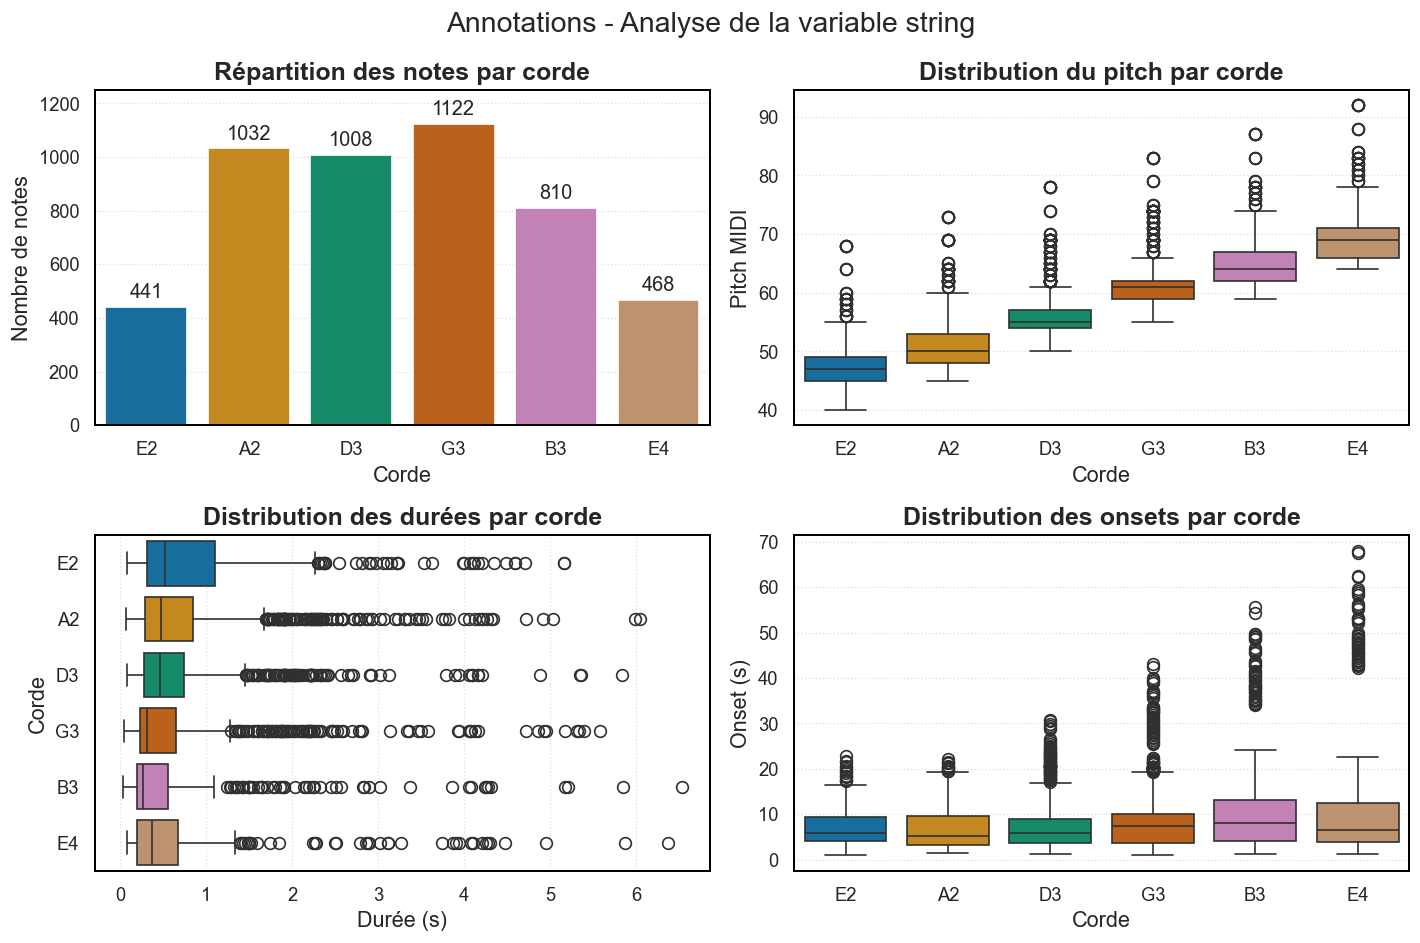

In [ ]:
notes_per_string = (
    df_annotation.groupby("string")["onset"].count().reindex(STRING_ORDER)
)

string_color = {
    "E2": COLORBLIND_PALETTE[0],
    "A2": COLORBLIND_PALETTE[1],
    "D3": COLORBLIND_PALETTE[2],
    "G3": COLORBLIND_PALETTE[3],
    "B3": COLORBLIND_PALETTE[4],
    "E4": COLORBLIND_PALETTE[5],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle("Annotations - Analyse de la variable string", fontsize=17)

axes = axes.flatten()

# ===
# Répartition des notes par cordes
# ===
ax1 = axes[0]
barplot = sns.barplot(
    x=notes_per_string.index,
    y=notes_per_string.values,
    palette=string_color,
    hue=notes_per_string.index,
    legend=False,
    ax=ax1,
)
ax1.set_title("Répartition des notes par corde")
ax1.set_xlabel("Corde")
ax1.set_ylabel("Nombre de notes")
ax1.set_ylim(0, 1250)

for container in barplot.containers:
    labels = [f"{v:.0f}" for v in container.datavalues]
    barplot.bar_label(container, padding=3, labels=labels)

# ===
# Répartition des pitch par cordes
# ===
ax2 = axes[1]
sns.boxplot(
    data=df_annotation,
    x="string",
    y="pitch",
    order=STRING_ORDER,
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax2,
)
ax2.set_xlabel("Corde")
ax2.set_ylabel("Pitch MIDI")
ax2.set_title("Distribution du pitch par corde")

# ===
# Répartition des durées par cordes
# ===
ax3 = axes[2]
sns.boxplot(
    data=df_annotation,
    x="duration",
    y="string",
    order=STRING_ORDER,
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax3,
)
ax3.set_xlabel("Durée (s)")
ax3.set_ylabel("Corde")
ax3.set_title("Distribution des durées par corde")

# ===
# Répartition des onsets par cordes
# ===
ax4 = axes[3]
sns.boxplot(
    data=df_annotation,
    x="string",
    y="onset",
    order=STRING_ORDER,
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax4,
)
ax4.set_xlabel("Corde")
ax4.set_ylabel("Onset (s)")
ax4.set_title("Distribution des onsets par corde")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "annotation_string_analysis.png").as_posix())
plt.show()

Observations :
- La répartition des notes par corde est déséquilibrée. Il y a moins de notes sur les cordes E2 et E4 que sur les autres cordes.
- La répartition du pitch par corde révèle le chevauchement des notes par cordes et semble globalement cohérent avec la physique réelle de l'instruement. On retrouve les harmoniques au travers des outliers les plus extrèmes de chaque boxplot.
- La répartition des durées par corde montre que les notes graves ont globalement tendance à durer plus longtemps que les notes aigües. On note cependant que les notes de la corde E4, qui sont des notes aigües, ont une durée moyenne anormalement longue.
- La répartition des onset par corde indique que des notes aigües sont jouées tardivement dans les audios. On note la présence de nombreuses valeurs extrèmes.

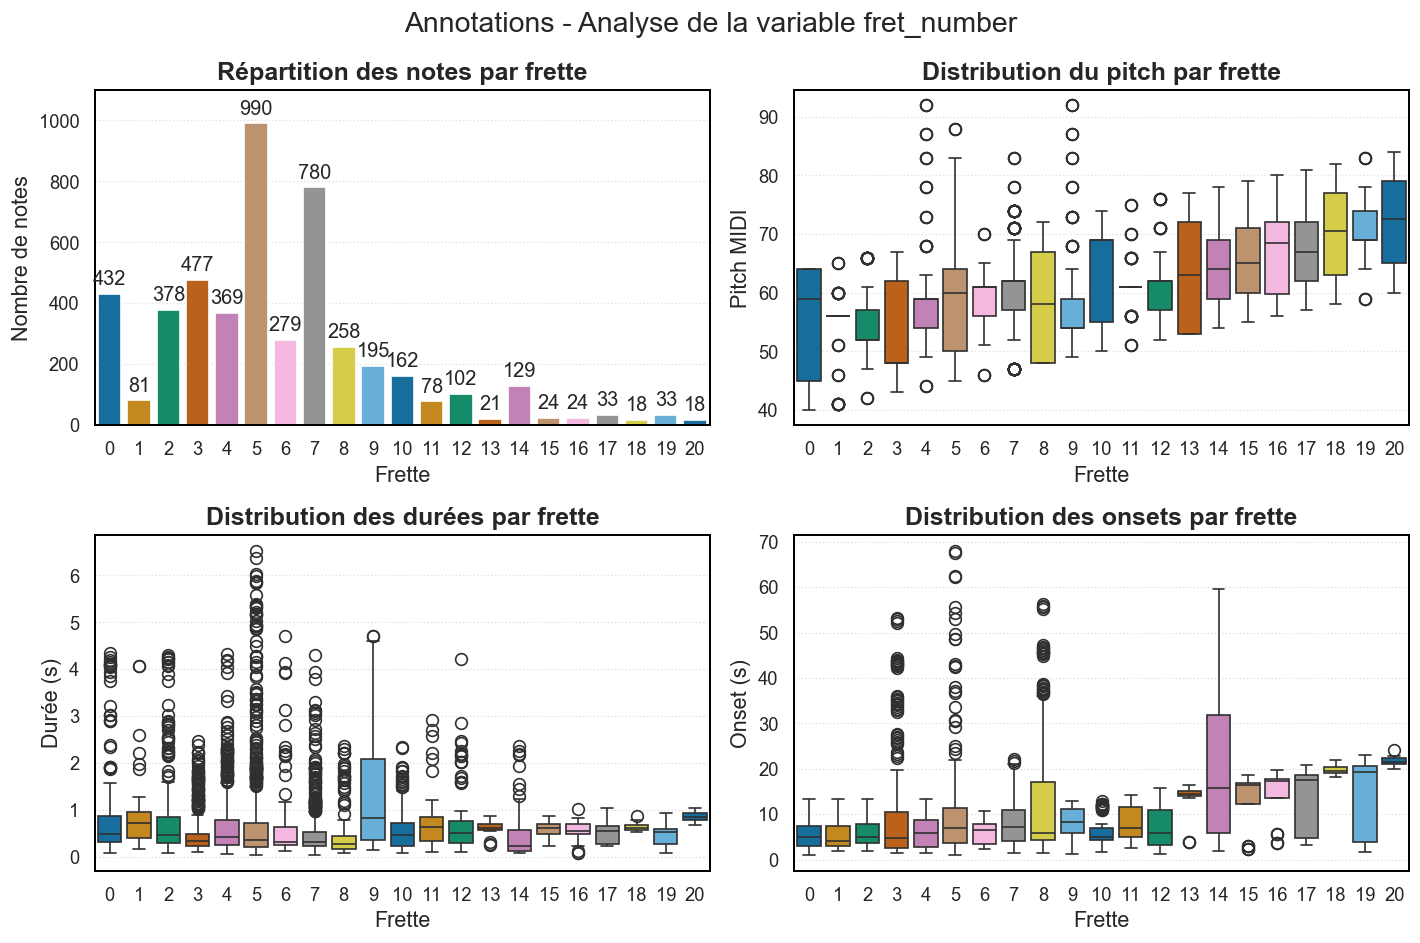

In [75]:
notes_per_fret = df_annotation.groupby("fret_number")["onset"].count()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle("Annotations - Analyse de la variable fret_number", fontsize=17)

axes = axes.flatten()

# ===
# Répartition des notes par frettes
# ===
ax1 = axes[0]
barplot = sns.barplot(
    x=notes_per_fret.index,
    y=notes_per_fret.values,
    palette=COLORBLIND_PALETTE,
    hue=notes_per_fret.index,
    legend=False,
    ax=ax1,
)
ax1.set_title("Répartition des notes par frette")
ax1.set_xlabel("Frette")
ax1.set_ylabel("Nombre de notes")
ax1.set_ylim(0, 1100)

for container in barplot.containers:
    labels = [f"{v:.0f}" for v in container.datavalues]
    barplot.bar_label(container, padding=3, labels=labels)

# ===
# Répartition des pitch par frettes
# ===
ax2 = axes[1]
sns.boxplot(
    data=df_annotation,
    x="fret_number",
    y="pitch",
    palette=COLORBLIND_PALETTE,
    hue="fret_number",
    legend=False,
    ax=ax2,
)
ax2.set_xlabel("Frette")
ax2.set_ylabel("Pitch MIDI")
ax2.set_title("Distribution du pitch par frette")

# ===
# Répartition des durées par frettes
# ===
ax3 = axes[2]
sns.boxplot(
    data=df_annotation,
    x="fret_number",
    y="duration",
    palette=COLORBLIND_PALETTE,
    hue="fret_number",
    legend=False,
    ax=ax3,
)
ax3.set_xlabel("Frette")
ax3.set_ylabel("Durée (s)")
ax3.set_title("Distribution des durées par frette")

# ===
# Répartition des onsets par frettes
# ===
ax4 = axes[3]
sns.boxplot(
    data=df_annotation,
    x="fret_number",
    y="onset",
    palette=COLORBLIND_PALETTE,
    hue="fret_number",
    legend=False,
    ax=ax4,
)
ax4.set_xlabel("Frette")
ax4.set_ylabel("Onset (s)")
ax4.set_title("Distribution des onsets par frette")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "annotation_fret_analysis.png").as_posix())
plt.show()

Observations :
- La répartition des notes par frette est déséquilibrée. La majoritée des notes sont jouées sur les 10 premières frettes. On note que la frette 1 est sous représentée par rapport au frettes voisines et que les frettes 5 et 7 sont sur représentées par rapport au frettes voisines. Ce biais provient probablement des gammes utilisées dans les audios.
- La répartition du pitch par frette semble cohérent avec la physique réelle de l'instruement. On retrouve les harmoniques avec les outliers en frettes 4 et 9 pour les audios dont le titre contient '_NH_' et les outliers en frette 5 pour les audios dont le titre contient '_lick11_'.
- La distribution des durées par frette révèle que les notes les plus longues sont principalement situées sur les frettes 0 à 9. La frette 9 montre une distribution différente des autres frettes. Environ 50% des notes sur la frette 9 ont une durée supérieure à 0.8s.
- La répartition des onset par frette indique que les notes les plus aigües sont jouées plus tardivement. Ces notes peuvent correspondre à une partie solo qui est généralement jouée plus tardivement.

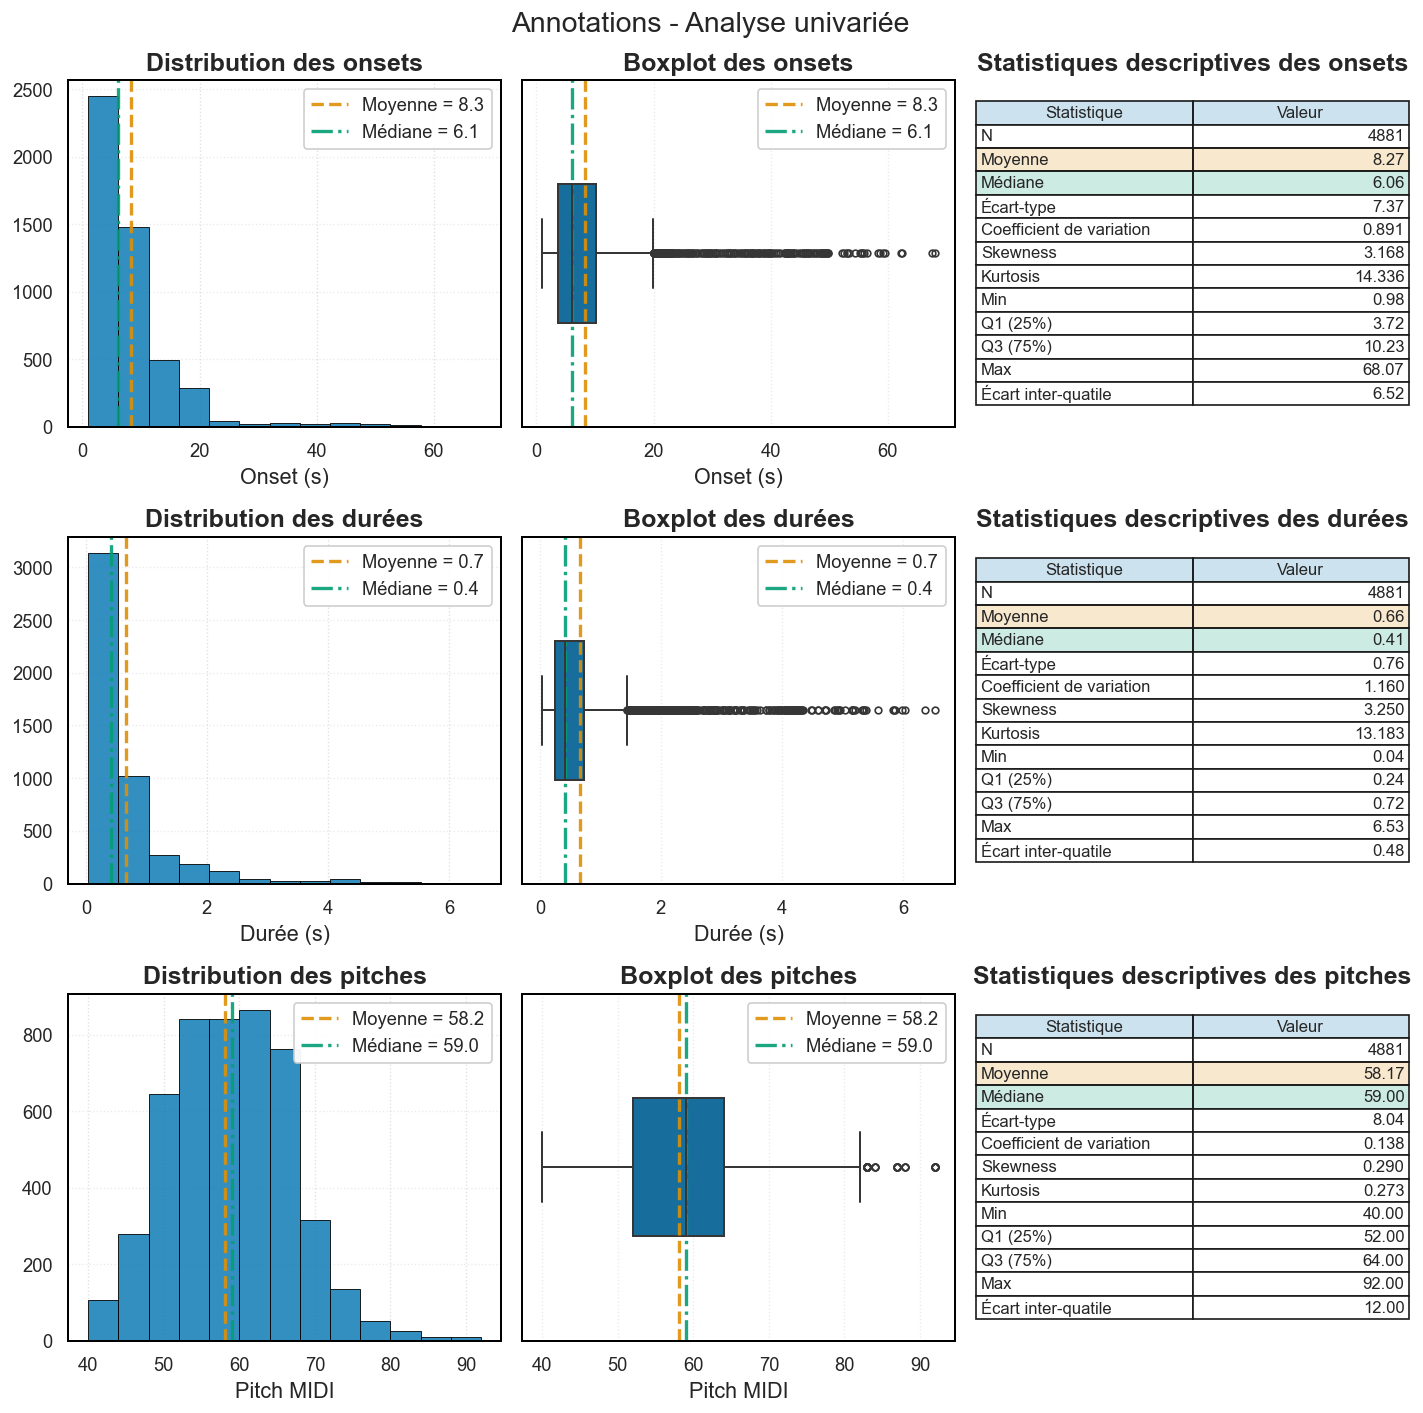

In [145]:
def create_histplot(ax, df, column):
    values = df[column].dropna()

    sns.histplot(
        x=values,
        # bins=int(np.sqrt(len(values))),
        bins=int(1 + np.log2(len(values))),
        color=COLORBLIND_PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_boxplot(ax, df, column):
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=COLORBLIND_PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_stats_panel(ax, df, column):
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(COLORBLIND_PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(COLORBLIND_PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(COLORBLIND_PALETTE[2] + (0.2,))

    ax.set_axis_off()


fig, axes = plt.subplots(3, 3, figsize=(12, 12))

fig.suptitle("Annotations - Analyse univariée", fontsize=17)

# ===
# Distribution des onsets
# ===
ax1 = axes[0, 0]
create_histplot(ax=ax1, df=df_annotation, column="onset")
ax1.set_title("Distribution des onsets")
ax1.set_xlabel("Onset (s)")
ax1.set_ylabel(None)

ax2 = axes[0, 1]
create_boxplot(ax2, df_annotation, "onset")
ax2.set_title("Boxplot des onsets")
ax2.set_xlabel("Onset (s)")

ax3 = axes[0, 2]
create_stats_panel(ax3, df_annotation, "onset")
ax3.set_title("Statistiques descriptives des onsets")

# ===
# Distribution des durées
# ===
ax4 = axes[1, 0]
create_histplot(ax=ax4, df=df_annotation, column="duration")
ax4.set_title("Distribution des durées")
ax4.set_xlabel("Durée (s)")
ax4.set_ylabel(None)

ax5 = axes[1, 1]
create_boxplot(ax5, df_annotation, "duration")
ax5.set_title("Boxplot des durées")
ax5.set_xlabel("Durée (s)")

ax6 = axes[1, 2]
create_stats_panel(ax6, df_annotation, "duration")
ax6.set_title("Statistiques descriptives des durées")

# ===
# Distribution des pitch
# ===
ax7 = axes[2, 0]
create_histplot(ax=ax7, df=df_annotation, column="pitch")
ax7.set_title("Distribution des pitches")
ax7.set_xlabel("Pitch MIDI")
ax7.set_ylabel(None)

ax8 = axes[2, 1]
create_boxplot(ax8, df_annotation, "pitch")
ax8.set_title("Boxplot des pitches")
ax8.set_xlabel("Pitch MIDI")

ax9 = axes[2, 2]
create_stats_panel(ax9, df_annotation, "pitch")
ax9.set_title("Statistiques descriptives des pitches")

plt.tight_layout()
plt.savefig(
    (
        FIGURES_DIRECTORY / "annotation_numerical_variables_distributions_1.png"
    ).as_posix()
)
plt.show()

Observations :
- Distribution des `onsets` :
  - Les onsets sont fortement concentrés sur les premières secondes des audios. Au moins la moitié se situe entre 0 et 6.06s. La distribution présente une longue queue allant jusqu'à 68.07s.
  - La différence importante entre moyenne et médiane ainsi qu'une skewness élevée (3.2) montre une forte asymétrie positive. Quelques événements tardifs allongent la distribution.
  - Le boxplot montre de nomberux outliers après 20s révèlant probablement des structures musicals irrégulières ou des silences suivis de reprises.
  - Le coefficient de variation est élevé (0.89) indiquant une forte variabilité.
- Distribution des durées (`duration`) :
  - La distribution des durées est très concentrée autour des valeurs faibles. La majorité des notes ont une durées inférieure à 0.41s. Quelques notes longues peuvent atteindre jusqu'à 6.53s.
  - Comme pour les onsets, la distribution est fortement asymétrique positive. Cela montre que le dataset contient énormément de notes courtes et très peu de notes longues.
  - Le boxplot montre de nombreux outliers pouvant être interprétés comme des notes tenues, la résonance de l'instrument ou encore des techniques de jeu.
  - La variabilité est élevée avec un coefficient de variation de 1.16.
- Distruviton des `pitch` :
  - La distribution des pitches est quasi-normale.
  - Les quartiles montrent une concentration autour du registre médian de la guitare.
  - Le nombre d'outliers est faible donc les pitch semblent propores.

Conclusions :
- La distribution des onsets montre que le dataset présente des audios avec des structures temporelles non uniforme.
- La distribution des durées est fortement asymétrique et contient de nombreuses valeurs extrêmes plausibles.
- La distribution des pitch semble stable et couvrir la tessiture de la guitare.

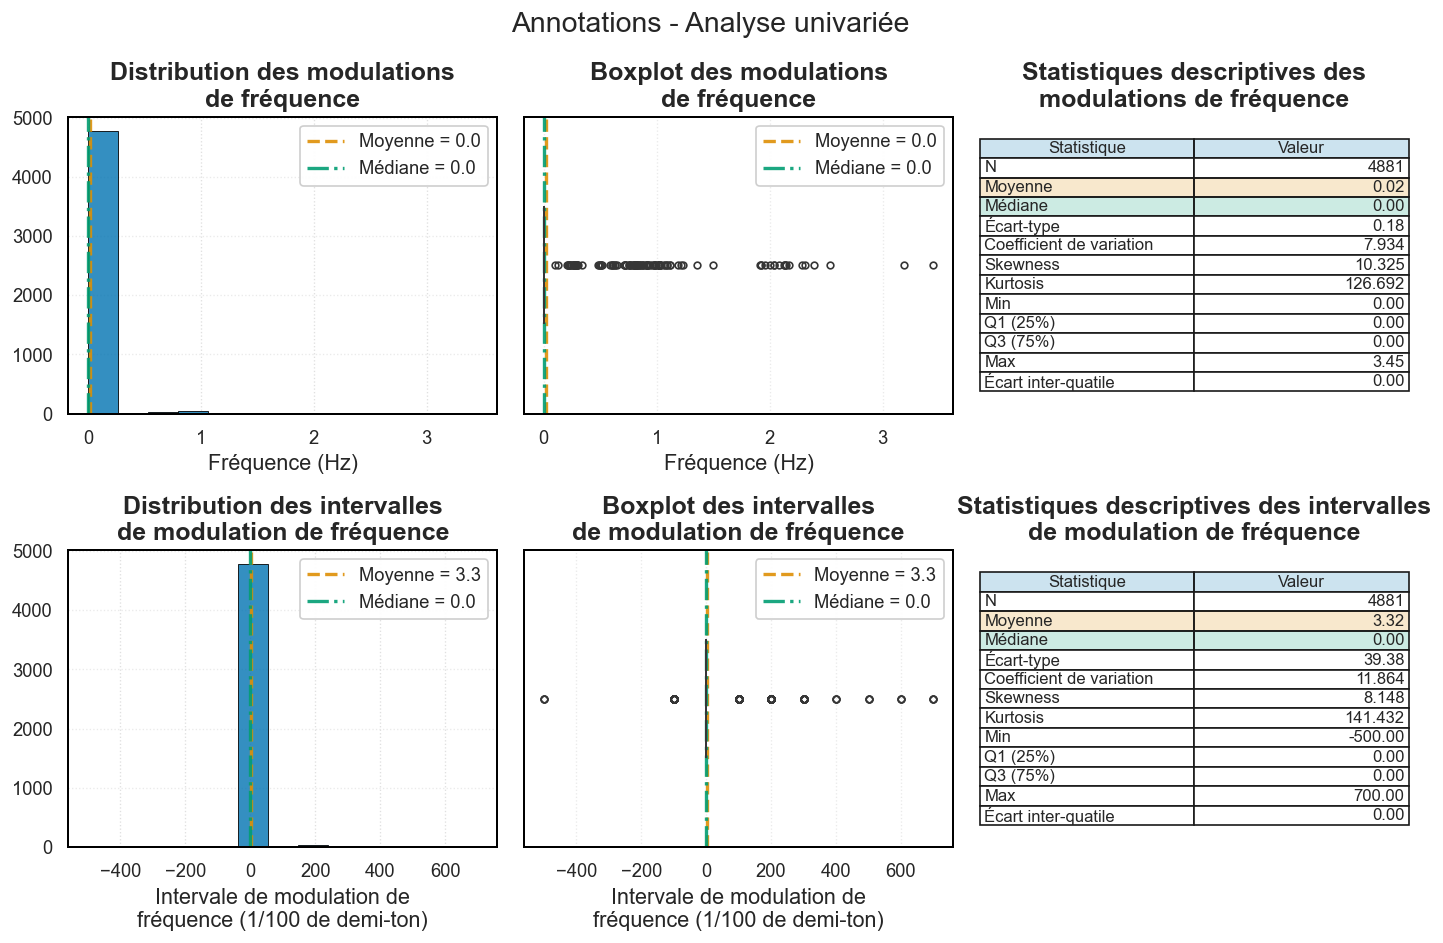

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

fig.suptitle("Annotations - Analyse univariée", fontsize=17)

# ===
# Distribution modulation_frequency
# ===
ax1 = axes[0, 0]
create_histplot(ax=ax1, df=df_annotation, column="modulation_frequency")
ax1.set_title("Distribution des modulations\nde fréquence")
ax1.set_xlabel("Fréquence (Hz)")
ax1.set_ylabel(None)

ax2 = axes[0, 1]
create_boxplot(ax2, df_annotation, "modulation_frequency")
ax2.set_title("Boxplot des modulations\nde fréquence")
ax2.set_xlabel("Fréquence (Hz)")

ax3 = axes[0, 2]
create_stats_panel(ax3, df_annotation, "modulation_frequency")
ax3.set_title("Statistiques descriptives des\nmodulations de fréquence")

# ===
# Distribution modulation_frequency_range
# ===
ax4 = axes[1, 0]
create_histplot(ax=ax4, df=df_annotation, column="modulation_frequency_range")
ax4.set_title("Distribution des intervalles\nde modulation de fréquence")
ax4.set_xlabel("Intervale de modulation de\nfréquence (1/100 de demi-ton)")
ax4.set_ylabel(None)

ax5 = axes[1, 1]
create_boxplot(ax5, df_annotation, "modulation_frequency_range")
ax5.set_title("Boxplot des intervalles\nde modulation de fréquence")
ax5.set_xlabel("Intervale de modulation de\nfréquence (1/100 de demi-ton)")

ax6 = axes[1, 2]
create_stats_panel(ax6, df_annotation, "modulation_frequency_range")
ax6.set_title("Statistiques descriptives des intervalles\nde modulation de fréquence")

plt.tight_layout()
plt.savefig(
    (
        FIGURES_DIRECTORY / "annotation_numerical_variables_distributions_2.png"
    ).as_posix()
)
plt.show()

In [144]:
invalid_modulation = df_annotation[
    (
        (df_annotation["modulation_frequency"] == 0)
        & (df_annotation["modulation_frequency_range"] != 0)
    )
    | (
        (df_annotation["modulation_frequency"] > 0)
        & (df_annotation["modulation_frequency_range"] == 0)
    )
    | (df_annotation["modulation_frequency"] > 10)
    | (df_annotation["modulation_frequency_range"].abs() > 400)
]

valid_modulation = df_annotation[
    (df_annotation["modulation_frequency"] > 0)
    & (df_annotation["modulation_frequency_range"] != 0)
    & df_annotation["modulation_frequency"].between(0, 10)
    & df_annotation["modulation_frequency_range"].between(-400, 400)
]

print("Nombre de modulation valide   :", len(valid_modulation))
print("Nombre de modulation invalide :", len(invalid_modulation))

modulation_percentage = (
    len(df_annotation[df_annotation["modulation_frequency"] > 0])
    / len(df_annotation)
    * 100
)
print(f"Pourcentage de notes modulées : {modulation_percentage:.2f}%")

Nombre de modulation valide   : 99
Nombre de modulation invalide : 12
Pourcentage de notes modulées : 2.27%


Observations :
- Globalement peu de modulation de fréquence, environ 2,27%.
- Les valeurs de modulation fréquentielles semble cohérente, jusqu'à 3.45Hz. Cependant les intervalles de modulation de fréquence contiennent des valeurs abérantes, par exemple une modulation de 7 demi-tons. Ces valeurs correspondent probablement aux harmoniques.

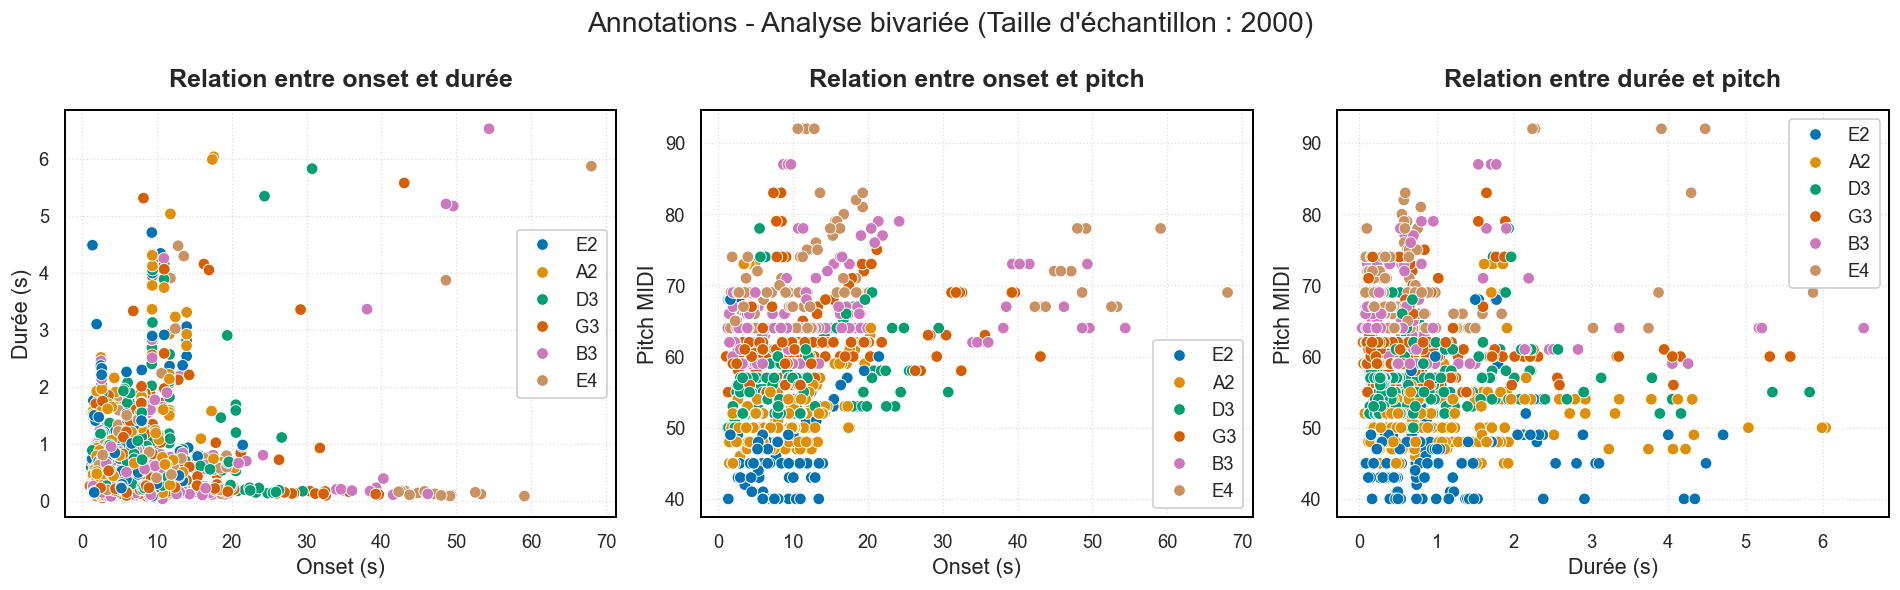

In [101]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

sample_size = 2000
df_annotation_sample = df_annotation.sample(sample_size, random_state=RANDOM_STATE)

fig.suptitle(
    f"Annotations - Analyse bivariée (Taille d'échantillon : {sample_size})",
    fontsize=17,
)

# ===
# Scatterplot onset vs duration
# ===

sns.scatterplot(
    data=df_annotation_sample,
    x="onset",
    y="duration",
    hue="string",
    hue_order=STRING_ORDER,
    palette=string_color,
    ax=ax1,
)
ax1.set_title("Relation entre onset et durée", pad=14)
ax1.set_xlabel("Onset (s)")
ax1.set_ylabel("Durée (s)")
ax1.legend()

# ===
# Scatterplot onset vs pitch
# ===

sns.scatterplot(
    data=df_annotation_sample,
    x="onset",
    y="pitch",
    hue="string",
    hue_order=STRING_ORDER,
    palette=string_color,
    ax=ax2,
)
ax2.set_title("Relation entre onset et pitch", pad=14)
ax2.set_xlabel("Onset (s)")
ax2.set_ylabel("Pitch MIDI")
ax2.legend()

# ===
# Scatterplot duration vs pitch
# ===

sns.scatterplot(
    data=df_annotation_sample,
    x="duration",
    y="pitch",
    hue="string",
    hue_order=STRING_ORDER,
    palette=string_color,
    ax=ax3,
)
ax3.set_title("Relation entre durée et pitch", pad=14)
ax3.set_xlabel("Durée (s)")
ax3.set_ylabel("Pitch MIDI")
ax3.legend()

plt.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "annotation_numerical_variables_scatterplot.png").as_posix()
)
plt.show()

Observations :
- Relation entre `onset` et `durée` : Aucun corrélation magnifeste.
- Relation entre `onset` et `pitch` : Aucun corrélation magnifeste. On retrouve le fait que des notes aigües sont jouées plus tardivement.
- Relation entre `pitch` et `durée` : On retrouve le fait que les notes grave durent plus longtemps que les notes aigües, cependant cette corrélation ne semble pas forte.

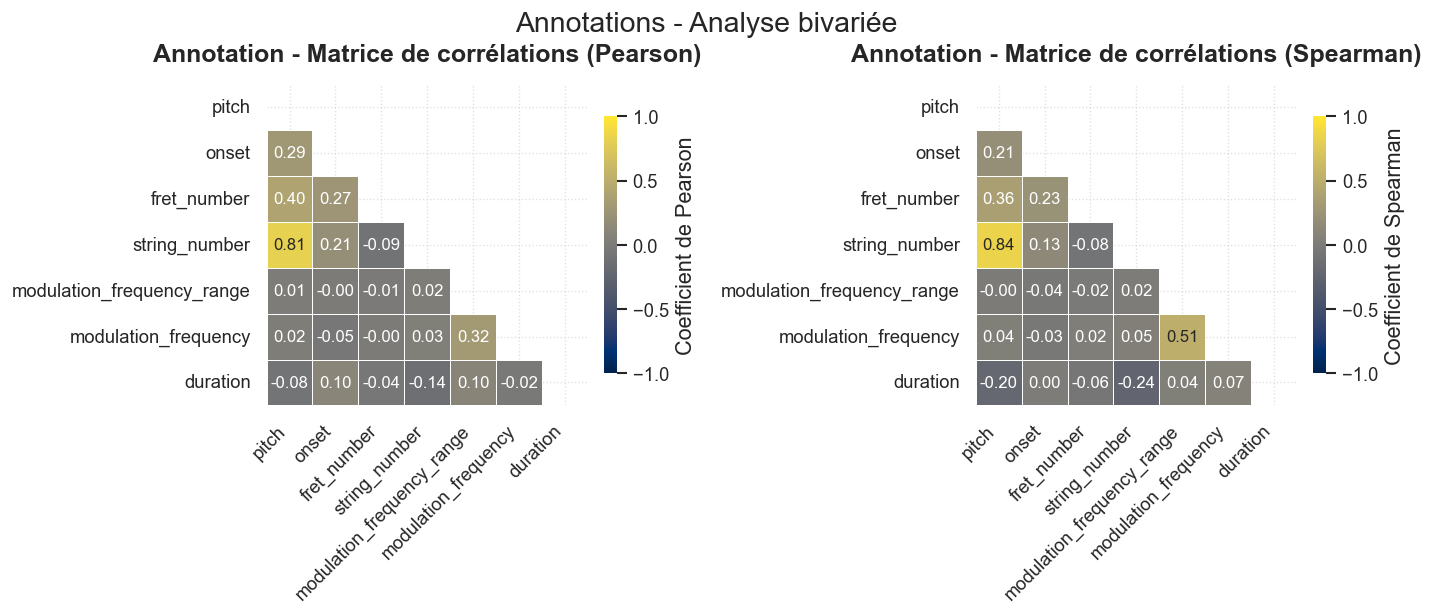

In [62]:
annotation_num_vars = [
    "pitch",
    "onset",
    "fret_number",
    "string_number",
    "modulation_frequency_range",
    "modulation_frequency",
    "duration",
]
annotation_corr_df_pearson = df_annotation[annotation_num_vars].corr(method="pearson")
annotation_corr_df_spearman = df_annotation[annotation_num_vars].corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Annotations - Analyse bivariée", fontsize=17)

# ===
# Pearson
# ===

heatmap = sns.heatmap(
    annotation_corr_df_pearson,
    mask=np.triu(np.ones_like(annotation_corr_df_pearson, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Annotation - Matrice de corrélations (Pearson)", pad=14)
ax1.set_xticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=45,
    ha="right",
)
ax1.set_yticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=0,
)

# ===
# Spearman
# ===

heatmap = sns.heatmap(
    annotation_corr_df_spearman,
    mask=np.triu(np.ones_like(annotation_corr_df_spearman, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Annotation - Matrice de corrélations (Spearman)", pad=14)
ax2.set_xticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=45,
    ha="right",
)
ax2.set_yticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=0,
)

plt.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "annotation_numerical_variables_correlations.png").as_posix()
)
plt.show()

#### Analyse polyphonie

In [103]:
df_annotation["simultaneous_group"] = (
    df_annotation.sort_values(["title", "onset"])
    .groupby("title")["onset"]
    .diff()
    .gt(0.02)  # 20ms
    .cumsum()
)

polyphony = df_annotation.groupby(["title", "simultaneous_group"]).size()

polyphony.describe()

count    4133.000000
mean        1.180982
std         0.685669
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
dtype: float64

## Audio (MinIO)

In [139]:
audio_objects = [
    obj
    for obj in minio.list_raw(prefix="IDMT-SMT-Guitar_2/")
    if "audio.wav" in obj.object_name
]

print("Nombre d'audio    :", len(audio_objects))
print("Taille total (Mo) :", sum(obj.size for obj in audio_objects) // (1024**2))

Nombre d'audio    : 261
Taille total (Mo) : 309


In [140]:
def analyze_silence_and_clipping(
    audio_data,
    sample_rate,
    silence_threshold=1e-4,
    clipping_threshold=0.99,
    silence_warning=20.0,
    silence_critical=60.0,
    clipping_warning=1.0,
    clipping_critical=10.0,
):
    def indices_to_segments(indices):
        if len(indices) == 0:
            return []

        splits = np.where(np.diff(indices) > 1)[0] + 1
        groups = np.split(indices, splits)

        return [(g[0] / sample_rate, g[-1] / sample_rate) for g in groups]

    # SILENCE
    silence_idx = np.where(np.abs(audio_data) < silence_threshold)[0]
    silence_ratio = len(silence_idx) / len(audio_data) * 100
    silence_segments = indices_to_segments(silence_idx)

    # DIAGNOSTIC
    if silence_ratio > silence_critical:
        silence_status = "mostly_silent"
    elif silence_ratio > silence_warning:
        silence_status = "partially_silent"
    else:
        silence_status = "clean"

    # CLIPPING
    clipping_idx = np.where(np.abs(audio_data) >= clipping_threshold)[0]
    clipping_ratio = len(clipping_idx) / len(audio_data) * 100
    clipping_segments = indices_to_segments(clipping_idx)

    # DIAGNOSTIC
    if clipping_ratio > clipping_critical:
        clipping_status = "heavily_distorted"
    elif clipping_ratio > clipping_warning:
        clipping_status = "saturated"
    else:
        clipping_status = "clean"

    return {
        "silence_ratio": silence_ratio,
        "silence_status": silence_status,
        "silence_segments": silence_segments,
        "silence_count": len(silence_segments),
        "clipping_ratio": clipping_ratio,
        "clipping_segments": clipping_segments,
        "clipping_count": len(clipping_segments),
        "clipping_status": clipping_status,
        "silence_indices": silence_idx,
        "clipping_indices": clipping_idx,
    }


audio_analysis = []

for obj in audio_objects:
    audio_data, sample_rate = minio.get_audio(
        bucket_name=MINIO_SETTINGS.bucket_raw,
        file_name=obj.object_name,
    )
    results = analyze_silence_and_clipping(audio_data, sample_rate)
    results["title"] = obj.object_name.split("/")[1]
    audio_analysis.append(
        {
            "title": obj.object_name.split("/")[1],
            "silence_ratio": results["silence_ratio"],
            "silence_status": results["silence_status"],
            "clipping_ratio": results["clipping_ratio"],
            "clipping_status": results["clipping_status"],
        }
    )

audio_analysis_df = pd.DataFrame(audio_analysis)

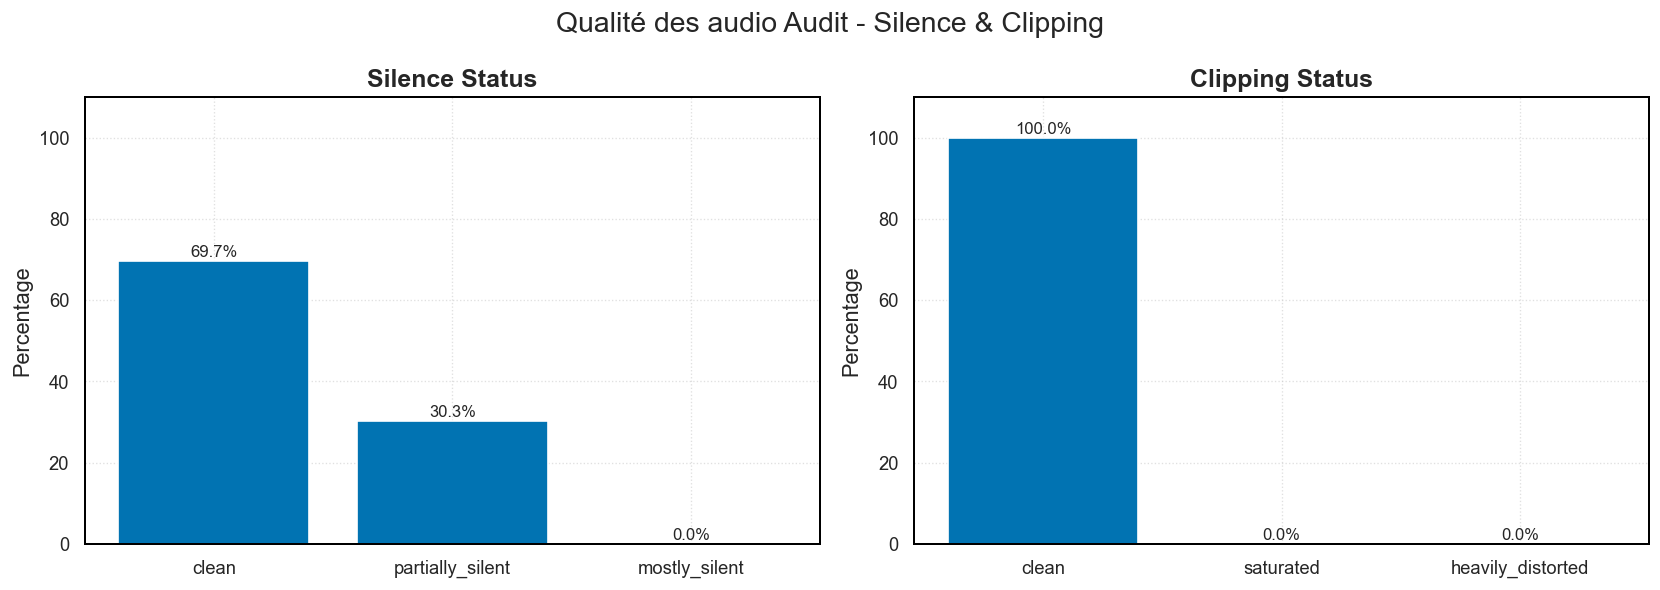

In [141]:
silence_order = ["clean", "partially_silent", "mostly_silent"]
clipping_order = ["clean", "saturated", "heavily_distorted"]

silence_counts = (
    audio_analysis_df["silence_status"]
    .value_counts()
    .reindex(silence_order, fill_value=0)
)
clipping_counts = (
    audio_analysis_df["clipping_status"]
    .value_counts()
    .reindex(clipping_order, fill_value=0)
)

silence_counts_norm = silence_counts / silence_counts.sum() * 100
clipping_counts_norm = clipping_counts / clipping_counts.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Qualité des audio Audit - Silence & Clipping", fontsize=17)

bars1 = ax1.bar(silence_counts_norm.index, silence_counts_norm.values)

ax1.set_title("Silence Status")
ax1.set_ylabel("Percentage")
ax1.set_ylim(0, 110)

for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.1f}%", ha="center", fontsize=10
    )

bars2 = ax2.bar(clipping_counts_norm.index, clipping_counts_norm.values)

ax2.set_title("Clipping Status")
ax2.set_ylabel("Percentage")
ax2.set_ylim(0, 110)

for bar in bars2:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.1f}%", ha="center", fontsize=10
    )

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "audio_silence_clipping.png").as_posix())
plt.show()

Observations :
- 30% des audios sont partiellement silencieux. La présence de ses silence peut perturber le modèle, un prétraitement pour supprimer ses silences et réligner les annotations peut être envisagé.
- Les audios sont sans distortion.